# Financial Analysis Homework 2: Volatility Modeling

    The Commercial Banking Corporation (hereafter the “Bank”), acting by and through its department of Portfolio Pricing is seeking proposals for banking services.

## Key Questions

    "How would have today's Dow constituents behaved historically (March 2011 - March 2021) in terms of volatility dynamics?"

    "If today’s Dow stocks had existed as a fixed portfolio historically, what volatility structure would we observe?"

## Main Framework Objectives

    1) Ranking all 30 stocks by LM test
    2) Selecting Top 5 to study
    3) Compare persistence and shock resposne (GARCH parameters)
    4) Volatility forecast comparison

Note: 
    
    "This study uses the current constituents of the Dow Jones Industrial Average and analyzes their historical volatility dynamics from March of 2011 to 2021"
    "econometric comparability"?

## Library

In [1]:
#%pip install yfinance pandas numpy matplotlib statsmodels arch

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model

## Objectives

### 1) Collecting of daily stock prices and daily returns for the 30 stocks in the Dow Jones Industrial Average (DJIA)

In [2]:
# Current 30 DJIA stocks
# Source list page: https://stockanalysis.com/list/dow-jones-stocks/
tickers = [
    "NVDA","AAPL","MSFT","AMZN","WMT","JPM","V","JNJ","HD","PG",
    "CVX","CAT","KO","CSCO","MRK","GS","UNH","IBM","AXP","MCD",
    "VZ","AMGN","DIS","BA","CRM","HON","NKE","SHW","MMM","TRV"
]

# Timeframe
START = "2011-03-01"
END   = "2021-03-24"

# Pull data
raw = yf.download(
    tickers,
    start=START,
    end=END,
    auto_adjust=True, 
    group_by="column",
    progress=False,
    threads=True
)

# Use adjusted close prices (auto_adjust=True gives "Close" already adjusted)
# Drop any rows where all price columns are null (e.g. data gaps due to holidays)
prices = raw["Close"].dropna(how="all")

# Returns (simple & log)
ret = prices.pct_change()
log_ret = np.log(prices).diff()

# Re-shaped table format for ARCH/GARCH modeling later
# Should be grouped by dates then tickers, with columns for price, ret, log_ret
df = (
    pd.concat(
        {
            "price": prices.stack(),
            "ret": ret.stack(),
            "log_ret": log_ret.stack(),
        },
        axis=1,
    )
    .reset_index()
    .rename(columns={"Date": "date", "level_1": "ticker"})
    .dropna() # this will cause 2011-03-01 data to be dropped since we don't have returns for that day (no previous price to compare to in 2011-02-28)
)

df.head()

,date,Ticker,price,ret,log_ret
30,2011-03-02,AAPL,10.550572,0.008044,0.008012
31,2011-03-02,AMGN,34.759605,-0.010018,-0.010068
32,2011-03-02,AMZN,8.601000,0.015227,0.015112
33,2011-03-02,AXP,34.910469,-0.003013,-0.003017
34,2011-03-02,BA,55.889294,-0.007844,-0.007874


We will be using Returns!

Why returns (not prices)?

    Prices tend to trend and are usually non-stationary
    Returns (especially log returns) are closer to stationary, making inference more reliable
    Volatility models (ARCH/GARCH) are designed for returns

Visualization

    Prices: long-run trend (not ideal for classic time series assumptions)
    Returns: fluctuations around ~0
    Returns often show volatility clustering: calm periods and stormy periods

#### (Optional) 1.1 Visualizing Price 

In [3]:
# for ticker in df["Ticker"].unique():

#     plot_df = df[df["Ticker"] == ticker]

#     plt.figure(figsize=(12,4))
#     plt.plot(plot_df["date"], plot_df["price"], linewidth=1.2)

#     plt.title(f"{ticker} Price (Adjusted)")
#     plt.xlabel("Date")
#     plt.ylabel("Price")

#     plt.tight_layout()
#     plt.show()

#### (Optional) 1.2 Visualizing Daily Log Returns 

In [4]:
# for ticker in df["Ticker"].unique():

#     plot_df = df[df["Ticker"] == ticker]

#     plt.figure(figsize=(12,4))
#     plt.plot(plot_df["date"], plot_df["log_ret"]*100, linewidth=1.0)

#     plt.title(f"{ticker} Daily Log Returns (%)")
#     plt.xlabel("Date")
#     plt.ylabel("Log Return (%)")

#     plt.axhline(0, linewidth=1)
#     plt.tight_layout()
#     plt.show()

#### (Optional) 1.3 Visualizing Absolute Daily Log Returns (Volatility Clustering Proxy)

In [5]:
# for ticker in df["Ticker"].unique():

#     plot_df = df[df["Ticker"] == ticker].sort_values("date")

#     plt.figure(figsize=(12,4))
#     plt.plot(
#         plot_df["date"],
#         np.abs(plot_df["log_ret"] * 100),
#         linewidth=1.0
#     )

#     plt.title(f"{ticker} |Daily Log Returns| (%) — Volatility Clustering Proxy")
#     plt.xlabel("Date")
#     plt.ylabel("|Log Return| (%)")

#     plt.tight_layout()
#     plt.show()

### 2) Ranking these 30 stock components of the DJIA by most significant to be predicted with ARCH/GARCH modeling

#### 2.1 Lagrange Multiplier (LM) test for ARCH effects


    The Bank’s analysts recommend using the Lagrange Multiplier Lag 1 test p-values to make this ranking

What it tests (simple terms):

    Are today’s squared residuals related to past squared residuals?
    If yes, volatility is not constant and ARCH/GARCH may help.


In [6]:
# Suggested setup
LM_LAGS = 1          # number of ARCH lags to test
RET_COL = "log_ret"   # use "log_ret" (recommended) or "ret"

# Running ARCH LM test for each stock
rows = []

for ticker, g in df.groupby("Ticker"):
    # Sort and pull the return series
    y = g.sort_values("date")[RET_COL].dropna().astype(float)

    # het_arch expects a 1D array-like
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(y, maxlag=LM_LAGS)

    rows.append({
        "Ticker": ticker,
        "n_obs": len(y),
        "LM_lags": LM_LAGS,
        "LM_stat_chi2": lm_stat,
        "LM_pvalue_chi2": lm_pvalue,
        "F_stat": f_stat,
        "F_pvalue": f_pvalue
    })

lm_results = pd.DataFrame(rows)

# Ranking by the smallest LM p-value (strongest significant evidence of ARCH effects)
lm_ranked = lm_results.sort_values("LM_pvalue_chi2", ascending=True).reset_index(drop=True)
# Adding 1 to the index to start ranking from 1 instead of 0
lm_ranked.index = lm_ranked.index + 1

lm_ranked

,Ticker,n_obs,LM_lags,LM_stat_chi2,LM_pvalue_chi2,F_stat,F_pvalue
1,PG,2532,1,516.902684,1.997137e-114,649.048522,1.234556e-127
2,HON,2532,1,502.249610,3.079660e-111,626.094403,1.198357e-123
3,GS,2532,1,496.724862,4.904321e-110,617.525698,3.753602e-122
4,JPM,2532,1,457.365718,1.799534e-101,557.802266,1.306371e-111
5,MSFT,2532,1,445.910982,5.597678e-99,540.844475,1.402123e-108
6,BA,2532,1,333.350582,1.790759e-74,383.611514,1.210568e-79
7,TRV,2532,1,320.543880,1.102637e-71,366.736741,1.915985e-76
8,UNH,2532,1,279.790089,8.343329e-63,314.315041,2.209974e-66
9,JNJ,2532,1,245.472439,2.520718e-55,271.622101,4.796770e-58
10,AXP,2532,1,227.188146,2.446679e-51,249.394854,1.184344e-53


Interpretation:

    Small p-value → strong evidence of ARCH effects → volatility changes over time.

#### 2.2 Top 5 stock components ranked by the LM test

In [7]:
TOP5 = lm_ranked["Ticker"].head(5).tolist()

TOP5

['PG', 'HON', 'GS', 'JPM', 'MSFT']

PG: The Procter & Gamble Company

HON: Honeywell International Inc

GS: The Goldman Sachs Group, Inc.

JPM: JPMorgan Chase & Co.

MSFT: Microsoft Corporation

### 3) Creation of a series of five models to predict the volatility from the top five most significant stock components of the DJIA to be predicted with ARCH/GARCH modeling

#### 3.1 Data Splitting

- Train for estimating volatility dynamics
- Test for evaluating volatility forecast

In [8]:
HOLDOUT_DAYS = 252   # ~1 trading year

train_test_data = {}

for ticker in TOP5:

    # extract one ticker
    temp = (
        df[df["Ticker"] == ticker]
       
.sort_values("date")
        .set_index("date")
    )

    # log returns in percent (required by arch package)
    y_all = temp["log_ret"] * 100

    # split
    split_idx = len(y_all) - HOLDOUT_DAYS

    y_train = y_all.iloc[:split_idx]
    y_test  = y_all.iloc[split_idx:]

    train_test_data[ticker] = {
        "y_all": y_all,
        "y_train": y_train,
        "y_test": y_test,
        "train_dates": y_train.index,
        "test_dates": y_test.index
    }

# Sanity check on one example
train_test_data["PG"]["y_train"].shape, train_test_data["PG"]["y_test"].shape

((2280,), (252,))

In [9]:
# Safety Sanity Check
for t in TOP5:
    print(
        t,
        train_test_data[t]["y_train"].index.min(),
        train_test_data[t]["y_train"].index.max(),
        "| test:",
        train_test_data[t]["y_test"].index.min(),
        train_test_data[t]["y_test"].index.max()
    )

PG 2011-03-02 00:00:00 2020-03-23 00:00:00 | test: 2020-03-24 00:00:00 2021-03-23 00:00:00
HON 2011-03-02 00:00:00 2020-03-23 00:00:00 | test: 2020-03-24 00:00:00 2021-03-23 00:00:00
GS 2011-03-02 00:00:00 2020-03-23 00:00:00 | test: 2020-03-24 00:00:00 2021-03-23 00:00:00
JPM 2011-03-02 00:00:00 2020-03-23 00:00:00 | test: 2020-03-24 00:00:00 2021-03-23 00:00:00
MSFT 2011-03-02 00:00:00 2020-03-23 00:00:00 | test: 2020-03-24 00:00:00 2021-03-23 00:00:00


#### 3.2 Choosing the Best GARCH model for Each Top 5 Stock (BIC selection)

    GARCH(1,1)-Normal
    GARCH(1,1)-t
    QGARCH(1,1)-Normal
    QGARCH(1,1)-t

In [10]:
# Settings
MEAN_MODEL = "Constant"   # alternatives: "AR", "Zero"
VOL_MODEL  = "GARCH"
P, Q = 1, 1

# 4 required model variants
# Note: o=0 => standard GARCH; o=1 => asymmetric GJR-GARCH (often used as "QGARCH" proxy in coursework)
MODEL_SPECS = [
    {"name": "GARCH(1,1)-Normal",   "o": 0, "dist": "normal"},
    {"name": "GARCH(1,1)-t",        "o": 0, "dist": "t"},
    {"name": "QGARCH(1,1)-Normal",  "o": 1, "dist": "normal"},
    {"name": "QGARCH(1,1)-t",       "o": 1, "dist": "t"},
]

# Fitting the model for each stock
all_results = []          # summary rows (BIC etc.)
fit_objects = {}          # store fitted model objects if you need them later (forecasts, params)
param_rows  = []          # parameter interpretation rows (alpha1, beta1, persistence, half-life)

for ticker in TOP5:
    y_all = train_test_data[ticker]["y_all"]      # percent log returns, full series
    split_idx = len(y_all) - HOLDOUT_DAYS         # same logic as the split framework

    fit_objects[ticker] = {}

    for spec in MODEL_SPECS:
        try:
            am = arch_model(
                y_all,
                mean=MEAN_MODEL,
                vol=VOL_MODEL,
                p=P, o=spec["o"], q=Q,
                dist=spec["dist"],
                rescale=False
            )

            # Fit only on training window using last_obs
            # last_obs is the LAST training observation index position (0-based)
            res = am.fit(last_obs=split_idx - 1, disp="off")

            # ---- store fit object for later forecasting/diagnostics ----
            fit_objects[ticker][spec["name"]] = res

            # ---- model selection metrics ----
            all_results.append({
                "Ticker": ticker,
                "Model": spec["name"],
                "Dist": spec["dist"],
                "o_asym": spec["o"],
                "n_train": split_idx,
                "n_total": len(y_all),
                "loglik": res.loglikelihood,
                "AIC": res.aic,
                "BIC": res.bic
            })

            # ---- parameter interpretation (alpha1, beta1, persistence) ----
            params = res.params.copy()
            alpha1 = params.get("alpha[1]", np.nan)
            beta1  = params.get("beta[1]", np.nan)
            persistence = alpha1 + beta1

            # Optional: half-life in trading days (only defined if 0 < persistence < 1)
            if np.isfinite(persistence) and (persistence > 0) and (persistence < 1):
                half_life_days = np.log(0.5) / np.log(persistence)
            else:
                half_life_days = np.nan

            param_rows.append({
                "Ticker": ticker,
                "Model": spec["name"],
                "alpha1 (shock reaction)": alpha1,
                "beta1 (persistence)": beta1,
                "alpha1 + beta1": persistence,
                "half_life_days": half_life_days
            })

        except Exception as e:
            # keep going if one model fails for a ticker
            all_results.append({
                "Ticker": ticker,
                "Model": spec["name"],
                "Dist": spec["dist"],
                "o_asym": spec["o"],
                "n_train": split_idx,
                "n_total": len(y_all),
                "loglik": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "error": str(e)
            })

            # Also add an empty param row so merges stay clean
            param_rows.append({
                "Ticker": ticker,
                "Model": spec["name"],
                "alpha1 (shock reaction)": np.nan,
                "beta1 (persistence)": np.nan,
                "alpha1 + beta1": np.nan,
                "half_life_days": np.nan,
                "error": str(e)
            })

# -----------------------
# Assemble results tables
# -----------------------
results_df = pd.DataFrame(all_results)
param_df   = pd.DataFrame(param_rows)

# -----------------------
# Rank models by BIC within each ticker (lowest BIC is best)
# -----------------------
ranked = (
    results_df
    .dropna(subset=["BIC"])
    .sort_values(["Ticker", "BIC"], ascending=[True, True])
    .reset_index(drop=True)
)

# -----------------------
# Merge model selection + parameter interpretation
# -----------------------
model_summary = ranked.merge(
    param_df[["Ticker", "Model", "alpha1 (shock reaction)", "beta1 (persistence)", "alpha1 + beta1", "half_life_days"]],
    on=["Ticker", "Model"],
    how="left"
)

# -----------------------
# Best model per ticker (lowest BIC) + interpretable params
# -----------------------
best_models = (
    model_summary
    .sort_values(["Ticker", "BIC"], ascending=[True, True])
    .groupby("Ticker")
    .head(1)
    .reset_index(drop=True)
)

# Useful outputs:
# - model_summary: ranked + alpha/beta/persistence/half-life
# - ranked: all models sorted by BIC within ticker
# - best_models: best model per ticker with interpretable params

model_summary

,Ticker,Model,Dist,o_asym,n_train,n_total,loglik,AIC,BIC,alpha1 (shock reaction),beta1 (persistence),alpha1 + beta1,half_life_days
0,GS,"QGARCH(1,1)-t",t,1,2280,2532,-4121.931662,8255.863323,8290.252275,4.678163e-02,0.869425,0.916207,7.920499
1,GS,"GARCH(1,1)-t",t,0,2280,2532,-4132.422504,8274.845008,8303.502468,1.065662e-01,0.867917,0.974483,26.816348
2,GS,"QGARCH(1,1)-Normal",normal,1,2280,2532,-4182.315264,8374.630527,8403.287988,4.310962e-02,0.892976,0.936086,10.494542
3,GS,"GARCH(1,1)-Normal",normal,0,2280,2532,-4191.985022,8391.970044,8414.896012,9.451511e-02,0.877896,0.972411,24.775591
4,HON,"QGARCH(1,1)-t",t,1,2280,2532,-3422.380501,6856.761001,6891.149953,2.146361e-03,0.861155,0.863302,4.715569
5,HON,"GARCH(1,1)-t",t,0,2280,2532,-3455.241061,6920.482122,6949.139582,1.309134e-01,0.848414,0.979327,33.182105
6,HON,"QGARCH(1,1)-Normal",normal,1,2280,2532,-3493.683297,6997.366594,7026.024054,1.933259e-10,0.865353,0.865353,4.792945
7,HON,"GARCH(1,1)-Normal",normal,0,2280,2532,-3552.664156,7113.328312,7136.254280,1.151297e-01,0.851346,0.966476,20.327637
8,JPM,"QGARCH(1,1)-t",t,1,2280,2532,-3889.277221,7790.554441,7824.943393,1.707678e-02,0.860926,0.878003,5.327585
9,JPM,"GARCH(1,1)-t",t,0,2280,2532,-3916.819049,7843.638098,7872.295558,1.165515e-01,0.856667,0.973219,25.533908


In [11]:
ranked

,Ticker,Model,Dist,o_asym,n_train,n_total,loglik,AIC,BIC
0,GS,"QGARCH(1,1)-t",t,1,2280,2532,-4121.931662,8255.863323,8290.252275
1,GS,"GARCH(1,1)-t",t,0,2280,2532,-4132.422504,8274.845008,8303.502468
2,GS,"QGARCH(1,1)-Normal",normal,1,2280,2532,-4182.315264,8374.630527,8403.287988
3,GS,"GARCH(1,1)-Normal",normal,0,2280,2532,-4191.985022,8391.970044,8414.896012
4,HON,"QGARCH(1,1)-t",t,1,2280,2532,-3422.380501,6856.761001,6891.149953
5,HON,"GARCH(1,1)-t",t,0,2280,2532,-3455.241061,6920.482122,6949.139582
6,HON,"QGARCH(1,1)-Normal",normal,1,2280,2532,-3493.683297,6997.366594,7026.024054
7,HON,"GARCH(1,1)-Normal",normal,0,2280,2532,-3552.664156,7113.328312,7136.254280
8,JPM,"QGARCH(1,1)-t",t,1,2280,2532,-3889.277221,7790.554441,7824.943393
9,JPM,"GARCH(1,1)-t",t,0,2280,2532,-3916.819049,7843.638098,7872.295558


In [12]:
best_models

,Ticker,Model,Dist,o_asym,n_train,n_total,loglik,AIC,BIC,alpha1 (shock reaction),beta1 (persistence),alpha1 + beta1,half_life_days
0,GS,"QGARCH(1,1)-t",t,1,2280,2532,-4121.931662,8255.863323,8290.252275,0.046782,0.869425,0.916207,7.920499
1,HON,"QGARCH(1,1)-t",t,1,2280,2532,-3422.380501,6856.761001,6891.149953,0.002146,0.861155,0.863302,4.715569
2,JPM,"QGARCH(1,1)-t",t,1,2280,2532,-3889.277221,7790.554441,7824.943393,0.017077,0.860926,0.878003,5.327585
3,MSFT,"QGARCH(1,1)-t",t,1,2280,2532,-3833.935217,7679.870434,7714.259386,0.042668,0.795662,0.838330,3.930653
4,PG,"QGARCH(1,1)-t",t,1,2280,2532,-2921.593558,5855.187116,5889.576069,0.038170,0.837561,0.875731,5.223553


#### 3.2A Alternative View of the Output (Like the Codebook)

In [13]:
best_by_ticker = ranked.groupby("Ticker").head(1).reset_index(drop=True)
best_by_ticker

,Ticker,Model,Dist,o_asym,n_train,n_total,loglik,AIC,BIC
0,GS,"QGARCH(1,1)-t",t,1,2280,2532,-4121.931662,8255.863323,8290.252275
1,HON,"QGARCH(1,1)-t",t,1,2280,2532,-3422.380501,6856.761001,6891.149953
2,JPM,"QGARCH(1,1)-t",t,1,2280,2532,-3889.277221,7790.554441,7824.943393
3,MSFT,"QGARCH(1,1)-t",t,1,2280,2532,-3833.935217,7679.870434,7714.259386
4,PG,"QGARCH(1,1)-t",t,1,2280,2532,-2921.593558,5855.187116,5889.576069


In [14]:
ticker = "GS"
best_model_name = best_by_ticker.loc[best_by_ticker["Ticker"] == ticker, "Model"].iloc[0]
print(f"Best model for {ticker}: {best_model_name}")

best_res = fit_objects[ticker][best_model_name]
print(best_res.summary())

Best model for GS: QGARCH(1,1)-t
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -4121.93
Distribution:      Standardized Student's t   AIC:                           8255.86
Method:                  Maximum Likelihood   BIC:                           8290.25
                                              No. Observations:                 2279
Date:                      Thu, Feb 26 2026   Df Residuals:                     2278
Time:                              03:41:01   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
----------------------------------------------

In [15]:
ticker = "HON"
best_model_name = best_by_ticker.loc[best_by_ticker["Ticker"] == ticker, "Model"].iloc[0]
print(f"Best model for {ticker}: {best_model_name}")

best_res = fit_objects[ticker][best_model_name]
print(best_res.summary())

Best model for HON: QGARCH(1,1)-t
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3422.38
Distribution:      Standardized Student's t   AIC:                           6856.76
Method:                  Maximum Likelihood   BIC:                           6891.15
                                              No. Observations:                 2279
Date:                      Thu, Feb 26 2026   Df Residuals:                     2278
Time:                              03:41:01   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
-----------------------------------------------

In [16]:
ticker = "JPM"
best_model_name = best_by_ticker.loc[best_by_ticker["Ticker"] == ticker, "Model"].iloc[0]
print(f"Best model for {ticker}: {best_model_name}")

best_res = fit_objects[ticker][best_model_name]
print(best_res.summary())

Best model for JPM: QGARCH(1,1)-t
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3889.28
Distribution:      Standardized Student's t   AIC:                           7790.55
Method:                  Maximum Likelihood   BIC:                           7824.94
                                              No. Observations:                 2279
Date:                      Thu, Feb 26 2026   Df Residuals:                     2278
Time:                              03:41:01   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
---------------------------------------------------

In [17]:
ticker = "MSFT"
best_model_name = best_by_ticker.loc[best_by_ticker["Ticker"] == ticker, "Model"].iloc[0]
print(f"Best model for {ticker}: {best_model_name}")

best_res = fit_objects[ticker][best_model_name]
print(best_res.summary())

Best model for MSFT: QGARCH(1,1)-t
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3833.94
Distribution:      Standardized Student's t   AIC:                           7679.87
Method:                  Maximum Likelihood   BIC:                           7714.26
                                              No. Observations:                 2279
Date:                      Thu, Feb 26 2026   Df Residuals:                     2278
Time:                              03:41:01   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------

In [18]:
ticker = "PG"
best_model_name = best_by_ticker.loc[best_by_ticker["Ticker"] == ticker, "Model"].iloc[0]
print(f"Best model for {ticker}: {best_model_name}")

best_res = fit_objects[ticker][best_model_name]
print(best_res.summary())

Best model for PG: QGARCH(1,1)-t
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -2921.59
Distribution:      Standardized Student's t   AIC:                           5855.19
Method:                  Maximum Likelihood   BIC:                           5889.58
                                              No. Observations:                 2279
Date:                      Thu, Feb 26 2026   Df Residuals:                     2278
Time:                              03:41:01   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
------------------------------------------------

##### NOTE: All 5 of them had QGARCH(1,1)-t as the best fitting GARCH model

#### 3.2B COVID Analysis

In [19]:
# Settings
MEAN_MODEL = "Constant"
VOL_MODEL  = "GARCH"
P, Q = 1, 1

MODEL_SPECS = [
    {"name": "GARCH(1,1)-Normal",   "o": 0, "dist": "normal"},
    {"name": "GARCH(1,1)-t",        "o": 0, "dist": "t"},
    {"name": "QGARCH(1,1)-Normal",  "o": 1, "dist": "normal"},
    {"name": "QGARCH(1,1)-t",       "o": 1, "dist": "t"},
]

# Fitting
all_results = []
fit_objects = {}
param_rows  = []

for ticker in TOP5:
    y_all = train_test_data[ticker]["y_all"]
    split_idx = len(y_all) - HOLDOUT_DAYS
    fit_objects[ticker] = {}
    for spec in MODEL_SPECS:
        try:
            am = arch_model(
                y_all,
                mean=MEAN_MODEL,
                vol=VOL_MODEL,
                p=P, o=spec["o"], q=Q,
                dist=spec["dist"],
                rescale=False
            )
            res = am.fit(last_obs=split_idx - 1, disp="off")
            fit_objects[ticker][spec["name"]] = res
        except Exception as e:
            print(f"Failed {ticker} {spec['name']}: {e}")

# In-sample metrics
def qlike(realized, forecast):
    """QL loss: log(h) + r²/h"""
    return np.mean(np.log(forecast) + realized / forecast)

in_sample_metrics = []

for ticker in TOP5:
    y_all = train_test_data[ticker]["y_all"]
    split_idx = len(y_all) - HOLDOUT_DAYS
    y_train = y_all.iloc[:split_idx]
    realized_var = y_train.values ** 2

    for spec in MODEL_SPECS:
        res = fit_objects[ticker].get(spec["name"])
        if res is None:
            continue

        h = res.conditional_volatility[:split_idx] ** 2
        min_len = min(len(realized_var), len(h))
        rv = realized_var[-min_len:]
        hv = h[-min_len:]

        mse  = np.mean((rv - hv) ** 2)
        mae  = np.mean(np.abs(rv - hv))
        ql   = qlike(rv, hv)
        corr = np.corrcoef(rv, hv)[0, 1]

        in_sample_metrics.append({
            "Ticker": ticker,
            "Model":  spec["name"],
            "MSE":    mse,
            "MAE":    mae,
            "QLIKE":  ql,
            "Corr":   corr,
        })

df_in_sample = pd.DataFrame(in_sample_metrics)
df_in_sample = df_in_sample.set_index(["Ticker", "Model"])
print(df_in_sample.to_string(float_format="{:.6f}".format))

                                MSE      MAE    QLIKE  Corr
Ticker Model                                               
PG     GARCH(1,1)-Normal  16.988826 1.253704 0.865763   NaN
       GARCH(1,1)-t       16.969583 1.260383 0.866570   NaN
       QGARCH(1,1)-Normal 16.205355 1.233035 0.855527   NaN
       QGARCH(1,1)-t      15.932164 1.247463 0.856106   NaN
HON    GARCH(1,1)-Normal  33.054753 1.963721 1.280013   NaN
       GARCH(1,1)-t       32.579842 1.996961 1.281641   NaN
       QGARCH(1,1)-Normal 32.248082 1.945260 1.229266   NaN
       QGARCH(1,1)-t      32.299447 1.966612 1.230002   NaN
GS     GARCH(1,1)-Normal  85.897666 3.170297 1.840453   NaN
       GARCH(1,1)-t       84.283787 3.196132 1.840376   NaN
       QGARCH(1,1)-Normal 84.952956 3.153578 1.832552   NaN
       QGARCH(1,1)-t      81.852915 3.188083 1.834181   NaN
JPM    GARCH(1,1)-Normal  97.566151 2.965801 1.684160   NaN
       GARCH(1,1)-t       98.186236 3.001875 1.687149   NaN
       QGARCH(1,1)-Normal 97.398984 2.93

In [20]:
# Filter QGARCH(1,1)-t only
qgarch_t = df_in_sample.xs("QGARCH(1,1)-t", level="Model")
print(qgarch_t.to_string(float_format="{:.6f}".format))

             MSE      MAE    QLIKE  Corr
Ticker                                  
PG     15.932164 1.247463 0.856106   NaN
HON    32.299447 1.966612 1.230002   NaN
GS     81.852915 3.188083 1.834181   NaN
JPM    97.382107 2.965897 1.651645   NaN
MSFT   76.771231 2.812271 1.706748   NaN


### 3.3 Forecast on the Test Set for Evaluation of the chosen model

    Note: “Realized volatility” here is proxied by |return| or squared return at a daily frequency. True realized volatility is usually computed from intraday data.

In [21]:
import numpy as np
import pandas as pd
from arch import arch_model

HOLDOUT_DAYS = 252

MEAN_MODEL = "Constant"
VOL_MODEL = "GARCH"
P, Q = 1, 1
BEST_O = 1
BEST_DIST = "t"

holdout_tables = []
holdout_by_ticker = {}

for ticker in TOP5:
    y_all   = train_test_data[ticker]["y_all"].dropna().astype(float)  # percent log returns
    y_test  = train_test_data[ticker]["y_test"].dropna().astype(float)
    test_dates = train_test_data[ticker]["test_dates"]

    split_idx = len(y_all) - HOLDOUT_DAYS

    am = arch_model(
        y_all, mean=MEAN_MODEL, vol=VOL_MODEL,
        p=P, o=BEST_O, q=Q, dist=BEST_DIST,
        rescale=False
    )

    # Fit on training only, keep full index
    res = am.fit(last_obs=split_idx - 1, disp="off")

    # 1-step-ahead forecasts starting at first test obs
    f = res.forecast(horizon=1, start=split_idx, reindex=True)

    var_forecast = f.variance["h.1"].reindex(test_dates)      # percent^2
    realized_var = (y_test ** 2).reindex(test_dates)          # percent^2

    vol_df = pd.DataFrame({
        "date": test_dates,
        "Ticker": ticker,
        "vol_forecast_pct": np.sqrt(var_forecast),
        "realized_vol_pct": np.sqrt(realized_var)
    }).dropna()

    holdout_by_ticker[ticker] = vol_df
    holdout_tables.append(vol_df)

holdout_eval = pd.concat(holdout_tables, ignore_index=True)

holdout_eval

,date,Ticker,vol_forecast_pct,realized_vol_pct
0,2020-03-24,PG,5.456125,5.544513
1,2020-03-25,PG,5.105040,2.301842
2,2020-03-26,PG,4.830809,6.204560
3,2020-03-27,PG,4.455019,2.565080
4,2020-03-30,PG,4.167846,4.290757
...,...,...,...,...
1255,2021-03-17,MSFT,1.325656,0.282251
1256,2021-03-18,MSFT,1.898324,2.702394
1257,2021-03-19,MSFT,1.744213,0.160512
1258,2021-03-22,MSFT,1.677080,2.418965


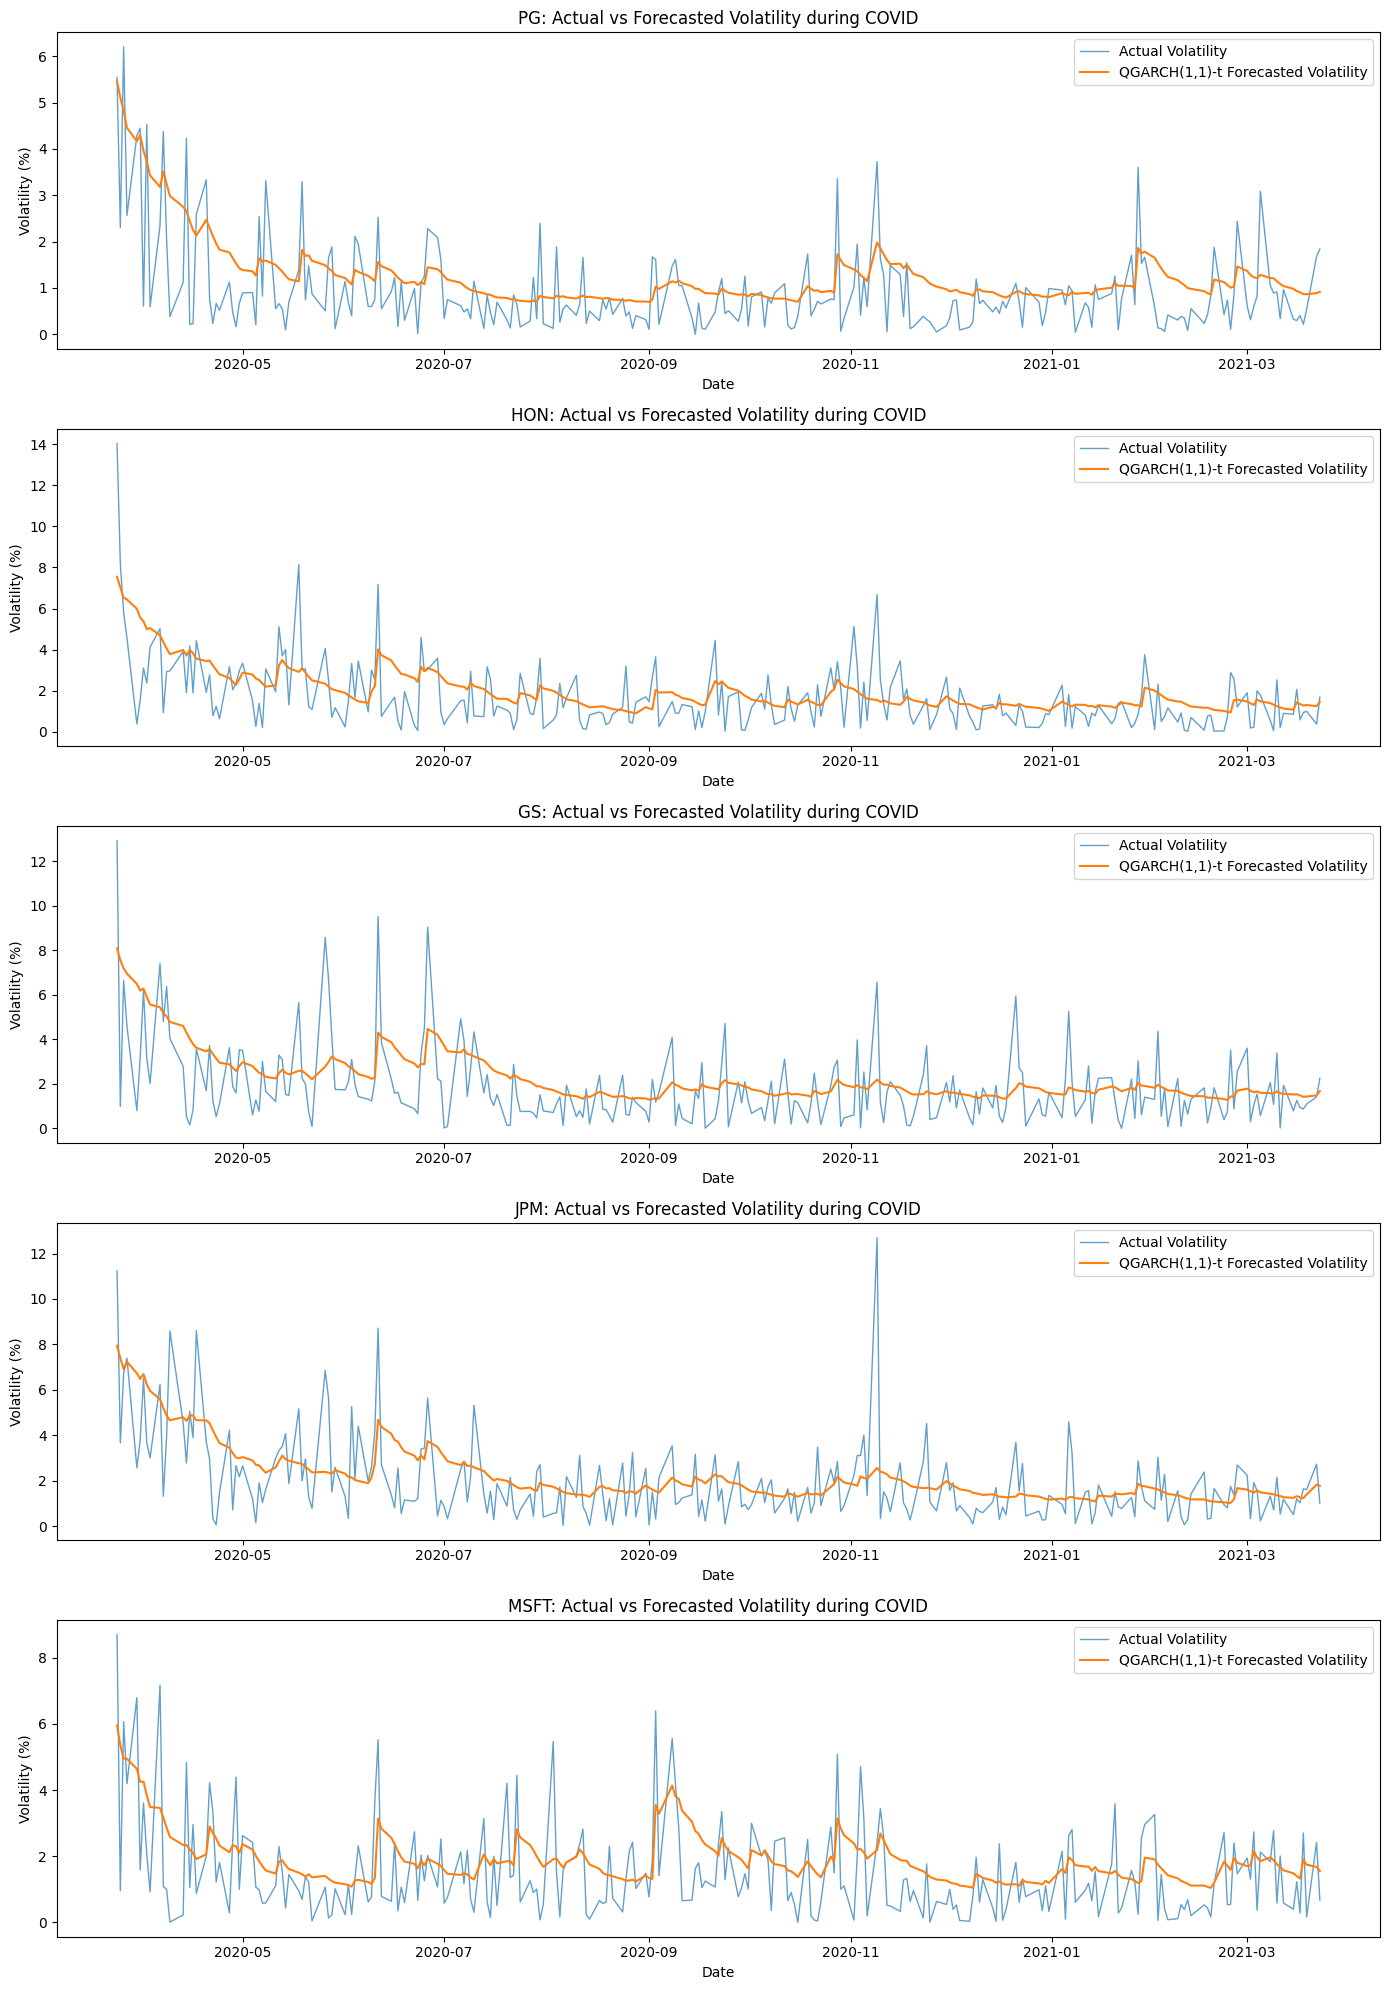

In [22]:
fig, axes = plt.subplots(len(TOP5), 1, figsize=(14, 4 * len(TOP5)), sharex=False)

for ax, ticker in zip(axes, TOP5):
    vol_df = holdout_by_ticker[ticker]
    
    ax.plot(vol_df["date"], vol_df["realized_vol_pct"], linewidth=1.0, label="Actual Volatility", alpha=0.7)
    ax.plot(vol_df["date"], vol_df["vol_forecast_pct"], linewidth=1.5, label="QGARCH(1,1)-t Forecasted Volatility")
    ax.set_title(f"{ticker}: Actual vs Forecasted Volatility during COVID")
    ax.set_xlabel("Date")
    ax.set_ylabel("Volatility (%)")
    ax.legend()

plt.tight_layout()
plt.show()

#### Performance Metrics of the Forecast on the Test Set

Volatility is not observed directly; we evaluate against a proxy such as squared returns.

Common, simple metrics:

    MSE on variance: average squared error between forecast variance and realized variance proxy
    MAE on variance: average absolute error
    QLIKE (quasi-likelihood loss): popular for volatility forecasts (lower is better)


In [23]:
metrics_tables = []

for ticker in TOP5:
    vol_df = holdout_by_ticker[ticker].set_index("date")
    
    vf = vol_df["vol_forecast_pct"] ** 2
    rv = vol_df["realized_vol_pct"] ** 2

    eps   = 1e-12
    mse   = np.mean((vf - rv) ** 2)
    mae   = np.mean(np.abs(vf - rv))
    qlike = np.mean(np.log(vf + eps) + (rv / (vf + eps)))
    corr  = np.corrcoef(np.sqrt(vf), np.sqrt(rv))[0, 1]

    metrics_tables.append({
        "Ticker": ticker,
        "MSE(var)":   mse,
        "MAE(var)":   mae,
        "QLIKE(var)": qlike,
        "Corr(vol_forecast, vol_realized)": corr
    })

metrics_eval = pd.DataFrame(metrics_tables).set_index("Ticker")
metrics_eval

,MSE(var),MAE(var),QLIKE(var),"Corr(vol_forecast, vol_realized)"
Ticker,,,,
PG,10.004435,1.667732,1.072282,0.650308
HON,136.658675,4.600334,2.223962,0.591599
GS,171.919070,6.208542,2.480699,0.524734
JPM,207.209885,6.098271,2.572748,0.566446
MSFT,44.391500,3.767965,2.058174,0.589595


How to interpret the evaluation:

    Lower MSE/MAE/QLIKE means the model’s variance forecasts are closer to the realized proxy.
    Positive correlation indicates the model tends to forecast higher volatility when volatility is indeed higher.

No single metric is perfect—volatility evaluation is inherently noisy.

### 3.4 Final Model with the Entire Dataset 

In [24]:
import numpy as np
import pandas as pd
from arch import arch_model

# Top 5 from your LM ranking
TOP5 = ['PG', 'HON', 'GS', 'JPM', 'MSFT']

# QGARCH(1,1)-t in arch:
# - vol="GARCH", p=1, o=1, q=1  (o=1 adds the asymmetric term; used as the QGARCH proxy)
# - dist="t"
MEAN_MODEL = "Constant"   # alternatives: "AR", "Zero"
VOL_MODEL  = "GARCH"
P, O, Q    = 1, 1, 1
DIST       = "t"

full_fit_results = {}   # store fitted results objects
full_fit_params  = []   # store parameter summary rows for a nice table

for ticker in TOP5:
    # Use the FULL series (March 2011 - March 2021), already in percent log returns
    y_all = train_test_data[ticker]["y_all"].dropna().astype(float)

    am = arch_model(
        y_all,
        mean=MEAN_MODEL,
        vol=VOL_MODEL,
        p=P, o=O, q=Q,
        dist=DIST,
        rescale=False
    )

    # Fit on the ENTIRE series (no last_obs here)
    res_full = am.fit(disp="off")

    # Store object (so you can forecast later)
    full_fit_results[ticker] = res_full

    # Collect interpretable parameters
    params = res_full.params.copy()
    alpha1 = params.get("alpha[1]", np.nan)
    beta1  = params.get("beta[1]", np.nan)
    gamma1 = params.get("gamma[1]", np.nan)  # asymmetry term (only present when o=1)
    nu     = params.get("nu", np.nan) 
    persistence = alpha1 + beta1  # common persistence metric (for GJR/QGARCH-like models too)

    full_fit_params.append({
        "Ticker": ticker,
        "Model": "QGARCH(1,1)-t",
        "n_obs": len(y_all),
        "loglik": res_full.loglikelihood,
        "AIC": res_full.aic,
        "BIC": res_full.bic,
        "alpha1 (shock reaction)": alpha1,
        "gamma1 (asymmetry)": gamma1,
        "beta1 (persistence)": beta1,
        "nu (tail thickness)": nu, 
        "alpha1 + beta1": persistence
    })

# Parameter/fit summary table
full_fit_summary = pd.DataFrame(full_fit_params).sort_values("BIC").reset_index(drop=True)

full_fit_summary

,Ticker,Model,n_obs,loglik,AIC,BIC,alpha1 (shock reaction),gamma1 (asymmetry),beta1 (persistence),nu (tail thickness),alpha1 + beta1
0,PG,"QGARCH(1,1)-t",2532,-3312.366947,6636.733895,6671.754483,0.038730,0.143823,0.836397,4.325699,0.875127
1,HON,"QGARCH(1,1)-t",2532,-3955.408155,7922.816311,7957.836900,0.014154,0.175162,0.882298,5.705849,0.896453
2,MSFT,"QGARCH(1,1)-t",2532,-4358.765002,8729.530005,8764.550593,0.042898,0.179239,0.829314,4.401623,0.872212
3,JPM,"QGARCH(1,1)-t",2532,-4461.877164,8935.754329,8970.774917,0.025020,0.152312,0.878493,5.288792,0.903513
4,GS,"QGARCH(1,1)-t",2532,-4689.751874,9391.503748,9426.524336,0.051978,0.088356,0.877314,5.805332,0.929292


In [25]:
full_fit_summary1 = pd.DataFrame(full_fit_params).sort_values("alpha1 (shock reaction)", ascending=False).reset_index(drop=True)

full_fit_summary1

,Ticker,Model,n_obs,loglik,AIC,BIC,alpha1 (shock reaction),gamma1 (asymmetry),beta1 (persistence),nu (tail thickness),alpha1 + beta1
0,GS,"QGARCH(1,1)-t",2532,-4689.751874,9391.503748,9426.524336,0.051978,0.088356,0.877314,5.805332,0.929292
1,MSFT,"QGARCH(1,1)-t",2532,-4358.765002,8729.530005,8764.550593,0.042898,0.179239,0.829314,4.401623,0.872212
2,PG,"QGARCH(1,1)-t",2532,-3312.366947,6636.733895,6671.754483,0.038730,0.143823,0.836397,4.325699,0.875127
3,JPM,"QGARCH(1,1)-t",2532,-4461.877164,8935.754329,8970.774917,0.025020,0.152312,0.878493,5.288792,0.903513
4,HON,"QGARCH(1,1)-t",2532,-3955.408155,7922.816311,7957.836900,0.014154,0.175162,0.882298,5.705849,0.896453


In [26]:
full_fit_summary2 = pd.DataFrame(full_fit_params).sort_values("beta1 (persistence)", ascending=False).reset_index(drop=True)

full_fit_summary2

,Ticker,Model,n_obs,loglik,AIC,BIC,alpha1 (shock reaction),gamma1 (asymmetry),beta1 (persistence),nu (tail thickness),alpha1 + beta1
0,HON,"QGARCH(1,1)-t",2532,-3955.408155,7922.816311,7957.836900,0.014154,0.175162,0.882298,5.705849,0.896453
1,JPM,"QGARCH(1,1)-t",2532,-4461.877164,8935.754329,8970.774917,0.025020,0.152312,0.878493,5.288792,0.903513
2,GS,"QGARCH(1,1)-t",2532,-4689.751874,9391.503748,9426.524336,0.051978,0.088356,0.877314,5.805332,0.929292
3,PG,"QGARCH(1,1)-t",2532,-3312.366947,6636.733895,6671.754483,0.038730,0.143823,0.836397,4.325699,0.875127
4,MSFT,"QGARCH(1,1)-t",2532,-4358.765002,8729.530005,8764.550593,0.042898,0.179239,0.829314,4.401623,0.872212


In [27]:
full_fit_summary3 = pd.DataFrame(full_fit_params).sort_values("alpha1 + beta1", ascending=False).reset_index(drop=True)

full_fit_summary3

,Ticker,Model,n_obs,loglik,AIC,BIC,alpha1 (shock reaction),gamma1 (asymmetry),beta1 (persistence),nu (tail thickness),alpha1 + beta1
0,GS,"QGARCH(1,1)-t",2532,-4689.751874,9391.503748,9426.524336,0.051978,0.088356,0.877314,5.805332,0.929292
1,JPM,"QGARCH(1,1)-t",2532,-4461.877164,8935.754329,8970.774917,0.025020,0.152312,0.878493,5.288792,0.903513
2,HON,"QGARCH(1,1)-t",2532,-3955.408155,7922.816311,7957.836900,0.014154,0.175162,0.882298,5.705849,0.896453
3,PG,"QGARCH(1,1)-t",2532,-3312.366947,6636.733895,6671.754483,0.038730,0.143823,0.836397,4.325699,0.875127
4,MSFT,"QGARCH(1,1)-t",2532,-4358.765002,8729.530005,8764.550593,0.042898,0.179239,0.829314,4.401623,0.872212


#### Alternative View

In [28]:
# like donnie's
for ticker in TOP5:
    print("\n" + "="*80)
    print(f"{ticker} — QGARCH(1,1)-t fitted on FULL sample (2011-03-01 to 2021-03-24)")
    print("="*80)
    print(full_fit_results[ticker].summary())


PG — QGARCH(1,1)-t fitted on FULL sample (2011-03-01 to 2021-03-24)
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3312.37
Distribution:      Standardized Student's t   AIC:                           6636.73
Method:                  Maximum Likelihood   BIC:                           6671.75
                                              No. Observations:                 2532
Date:                      Thu, Feb 26 2026   Df Residuals:                     2531
Time:                              03:41:03   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
------------

### 4) Forecasting of the next 30 days of volatility for each of the 5 models (Post March 2021)

In [29]:
# -----------------------
# Settings
# -----------------------
TOP5 = ['PG', 'HON', 'GS', 'JPM', 'MSFT']
HORIZON = 30

MEAN_MODEL = "Constant"
VOL_MODEL  = "GARCH"
P, Q = 1, 1

# Best model (per your BIC): "QGARCH(1,1)-t"
# Implemented in arch as asymmetric GJR-GARCH with o=1 and Student-t errors
BEST_O = 1
BEST_DIST = "t"

# -----------------------
# 30-day ahead forecasts
# -----------------------
fcst_tables = {}     # per-ticker forecast dataframe
fcst_long = []       # combined long dataframe rows

for ticker in TOP5:
    y_all = train_test_data[ticker]["y_all"].dropna().astype(float)

    # Fit on FULL series so "next 30 days" is from the end of sample
    am = arch_model(
        y_all,
        mean=MEAN_MODEL,
        vol=VOL_MODEL,
        p=P, o=BEST_O, q=Q,
        dist=BEST_DIST,
        rescale=False
    )
    res_full = am.fit(disp="off")

    # 30-step-ahead forecast from last obs
    f = res_full.forecast(horizon=HORIZON, reindex=False)

    # Variance forecasts (percent^2) for horizons 1..30
    var_30 = f.variance.iloc[-1].values
    vol_30 = np.sqrt(var_30)  # convert to volatility in percent

    # Future business-day index
    last_date = y_all.index[-1]
    future_dates = pd.bdate_range(last_date, periods=HORIZON + 1)[1:]

    fcst_df = pd.DataFrame({
        "date": future_dates,
        "Ticker": ticker,
        "vol_forecast_pct": vol_30
    })

    fcst_tables[ticker] = fcst_df
    fcst_long.append(fcst_df)

forecast_30d = pd.concat(fcst_long, ignore_index=True)

# -----------------------
# Summary table (makes interpretation easy)
# -----------------------
forecast_summary = (
    forecast_30d
    .groupby("Ticker", as_index=False)
    .agg(
        mean_vol_30d_pct=("vol_forecast_pct", "mean"),
        median_vol_30d_pct=("vol_forecast_pct", "median"),
        min_vol_30d_pct=("vol_forecast_pct", "min"),
        max_vol_30d_pct=("vol_forecast_pct", "max"),
        end_vol_day30_pct=("vol_forecast_pct", lambda s: s.iloc[-1])
    )
    .sort_values("mean_vol_30d_pct", ascending=False)
    .reset_index(drop=True)
)

# Outputs you will use in report:
# - forecast_30d: full 30-day path per ticker
# - forecast_summary: compact interpretation table
forecast_30d

,date,Ticker,vol_forecast_pct
0,2021-03-24,PG,0.923854
1,2021-03-25,PG,0.932916
2,2021-03-26,PG,0.941418
3,2021-03-29,PG,0.949399
4,2021-03-30,PG,0.956896
...,...,...,...
145,2021-04-28,MSFT,1.735009
146,2021-04-29,MSFT,1.738306
147,2021-04-30,MSFT,1.741471
148,2021-05-03,MSFT,1.744510


#### Forecast Summary

In [30]:
forecast_summary

,Ticker,mean_vol_30d_pct,median_vol_30d_pct,min_vol_30d_pct,max_vol_30d_pct,end_vol_day30_pct
0,JPM,1.778577,1.780001,1.750020,1.801945,1.801945
1,GS,1.724959,1.727365,1.686806,1.754309,1.754309
2,MSFT,1.682416,1.690781,1.586370,1.747427,1.747427
3,HON,1.448394,1.449738,1.415941,1.475958,1.475958
4,PG,1.004460,1.013324,0.923854,1.051496,1.051496


#### Plotting the 30-day forecasts

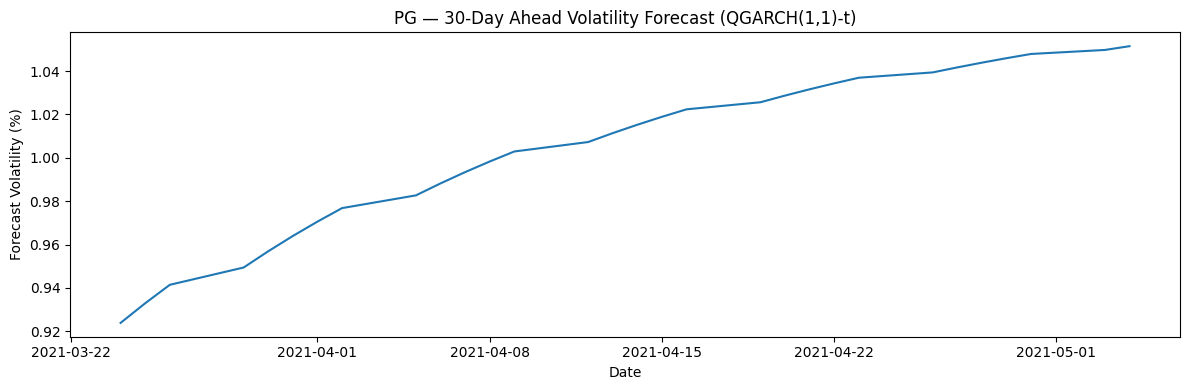

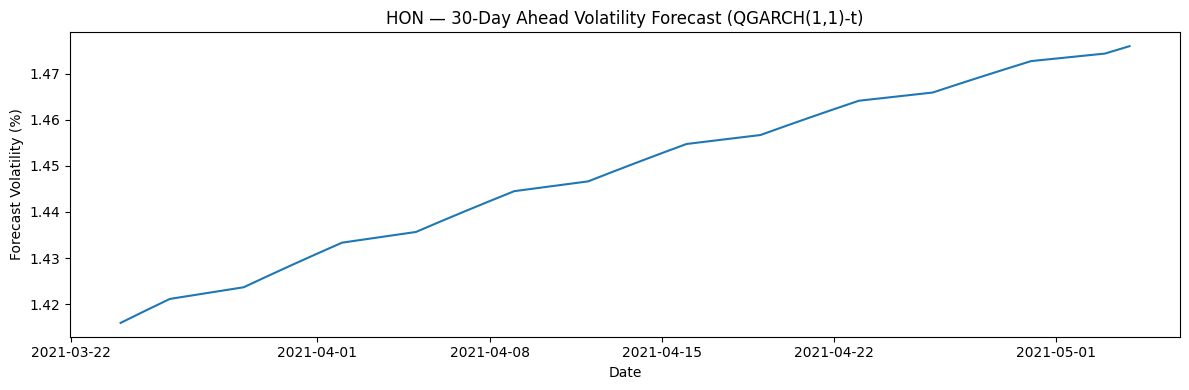

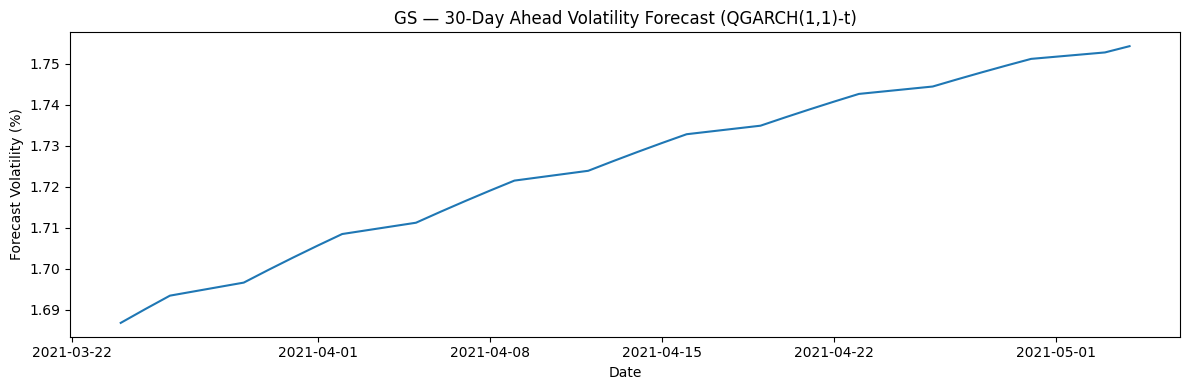

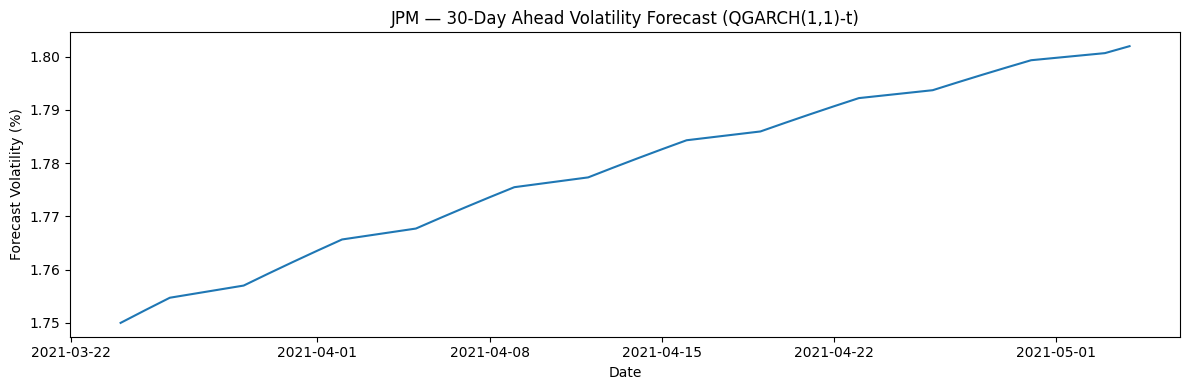

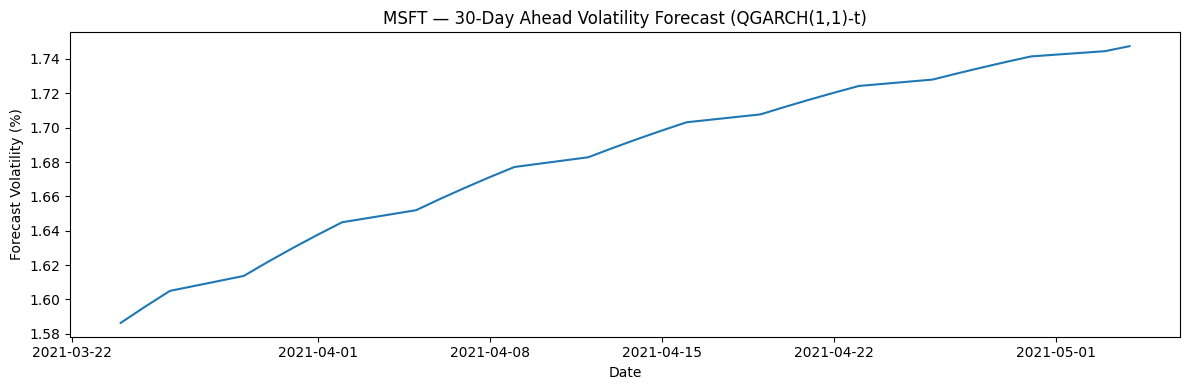

In [31]:
for ticker in TOP5:
    fcst_df = fcst_tables[ticker]

    plt.figure(figsize=(12,4))
    plt.plot(fcst_df["date"], fcst_df["vol_forecast_pct"], linewidth=1.5)

    plt.title(f"{ticker} — 30-Day Ahead Volatility Forecast (QGARCH(1,1)-t)")
    plt.xlabel("Date")
    plt.ylabel("Forecast Volatility (%)")

    plt.tight_layout()
    plt.show()

#### Single Chart Overlay

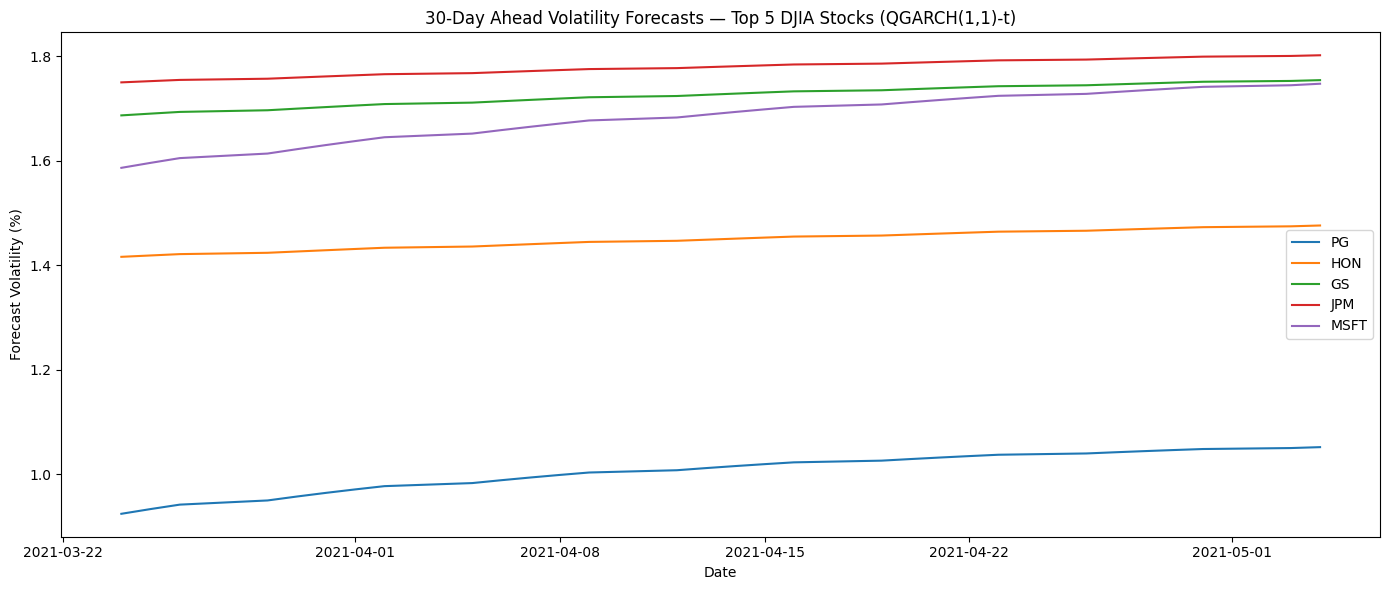

In [32]:
plt.figure(figsize=(14,6))

for ticker in TOP5:
    fcst_df = fcst_tables[ticker]
    plt.plot(fcst_df["date"], fcst_df["vol_forecast_pct"], linewidth=1.5, label=ticker)

plt.title("30-Day Ahead Volatility Forecasts — Top 5 DJIA Stocks (QGARCH(1,1)-t)")
plt.xlabel("Date")
plt.ylabel("Forecast Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

### 5) Rank these five stocks by order of most likely to be bothered by a shock to the market today

#### USE THIS INSTEAD 

    The previous code used the model from the training set, not on the full dataset!

In [33]:
full_fit_summary1 = pd.DataFrame(full_fit_params).sort_values("alpha1 (shock reaction)", ascending=False).reset_index(drop=True)

full_fit_summary1

,Ticker,Model,n_obs,loglik,AIC,BIC,alpha1 (shock reaction),gamma1 (asymmetry),beta1 (persistence),nu (tail thickness),alpha1 + beta1
0,GS,"QGARCH(1,1)-t",2532,-4689.751874,9391.503748,9426.524336,0.051978,0.088356,0.877314,5.805332,0.929292
1,MSFT,"QGARCH(1,1)-t",2532,-4358.765002,8729.530005,8764.550593,0.042898,0.179239,0.829314,4.401623,0.872212
2,PG,"QGARCH(1,1)-t",2532,-3312.366947,6636.733895,6671.754483,0.038730,0.143823,0.836397,4.325699,0.875127
3,JPM,"QGARCH(1,1)-t",2532,-4461.877164,8935.754329,8970.774917,0.025020,0.152312,0.878493,5.288792,0.903513
4,HON,"QGARCH(1,1)-t",2532,-3955.408155,7922.816311,7957.836900,0.014154,0.175162,0.882298,5.705849,0.896453


We look at alpha

In [34]:
shock_ranking = (
    best_models
    .sort_values("alpha1 (shock reaction)", ascending=False)
    .reset_index(drop=True)
)

shock_ranking[[
    "Ticker",
    "alpha1 (shock reaction)",
    "beta1 (persistence)",
    "alpha1 + beta1"
]]

,Ticker,alpha1 (shock reaction),beta1 (persistence),alpha1 + beta1
0,GS,0.046782,0.869425,0.916207
1,MSFT,0.042668,0.795662,0.838330
2,PG,0.038170,0.837561,0.875731
3,JPM,0.017077,0.860926,0.878003
4,HON,0.002146,0.861155,0.863302


### 6) Rank these five stocks by order of longest effect a shock lasts; compare this to the previous ranking and interpret. 

#### USE THIS INSTEAD

    The previous code used the model from the training set, not on the full dataset!

In [35]:
full_fit_summary3 = pd.DataFrame(full_fit_params).sort_values("alpha1 + beta1", ascending=False).reset_index(drop=True)

full_fit_summary3

,Ticker,Model,n_obs,loglik,AIC,BIC,alpha1 (shock reaction),gamma1 (asymmetry),beta1 (persistence),nu (tail thickness),alpha1 + beta1
0,GS,"QGARCH(1,1)-t",2532,-4689.751874,9391.503748,9426.524336,0.051978,0.088356,0.877314,5.805332,0.929292
1,JPM,"QGARCH(1,1)-t",2532,-4461.877164,8935.754329,8970.774917,0.025020,0.152312,0.878493,5.288792,0.903513
2,HON,"QGARCH(1,1)-t",2532,-3955.408155,7922.816311,7957.836900,0.014154,0.175162,0.882298,5.705849,0.896453
3,PG,"QGARCH(1,1)-t",2532,-3312.366947,6636.733895,6671.754483,0.038730,0.143823,0.836397,4.325699,0.875127
4,MSFT,"QGARCH(1,1)-t",2532,-4358.765002,8729.530005,8764.550593,0.042898,0.179239,0.829314,4.401623,0.872212


We look at alpha + beta

In [36]:
persistence_ranking = (
    best_models
    .sort_values("alpha1 + beta1", ascending=False)
    .reset_index(drop=True)
)

persistence_ranking[[
    "Ticker",
    "alpha1 (shock reaction)",
    "beta1 (persistence)",
    "alpha1 + beta1",
    "half_life_days"
]]

,Ticker,alpha1 (shock reaction),beta1 (persistence),alpha1 + beta1,half_life_days
0,GS,0.046782,0.869425,0.916207,7.920499
1,JPM,0.017077,0.860926,0.878003,5.327585
2,PG,0.038170,0.837561,0.875731,5.223553
3,HON,0.002146,0.861155,0.863302,4.715569
4,MSFT,0.042668,0.795662,0.838330,3.930653


In [37]:
half_life_ranking = (
    best_models
    .sort_values("half_life_days", ascending=False)
    .reset_index(drop=True)
)

half_life_ranking[[
    "Ticker",
    "alpha1 + beta1",
    "half_life_days"
]]

,Ticker,alpha1 + beta1,half_life_days
0,GS,0.916207,7.920499
1,JPM,0.878003,5.327585
2,PG,0.875731,5.223553
3,HON,0.863302,4.715569
4,MSFT,0.838330,3.930653


In [38]:
comparison = shock_ranking.merge(
    persistence_ranking[["Ticker"]],
    on="Ticker",
    suffixes=("_shock_rank", "_persistence_rank")
)

comparison

,Ticker,Model,Dist,o_asym,n_train,n_total,loglik,AIC,BIC,alpha1 (shock reaction),beta1 (persistence),alpha1 + beta1,half_life_days
0,GS,"QGARCH(1,1)-t",t,1,2280,2532,-4121.931662,8255.863323,8290.252275,0.046782,0.869425,0.916207,7.920499
1,MSFT,"QGARCH(1,1)-t",t,1,2280,2532,-3833.935217,7679.870434,7714.259386,0.042668,0.795662,0.838330,3.930653
2,PG,"QGARCH(1,1)-t",t,1,2280,2532,-2921.593558,5855.187116,5889.576069,0.038170,0.837561,0.875731,5.223553
3,JPM,"QGARCH(1,1)-t",t,1,2280,2532,-3889.277221,7790.554441,7824.943393,0.017077,0.860926,0.878003,5.327585
4,HON,"QGARCH(1,1)-t",t,1,2280,2532,-3422.380501,6856.761001,6891.149953,0.002146,0.861155,0.863302,4.715569
